In [18]:
%load_ext autoreload
%autoreload 2

import numpy as np
from scipy import linalg as la
from koala import plotting as pl
from alter_morph.hamiltonians import (
    alt_hamiltonian,
    find_m_per_state,
    find_spin_per_state,
    spectral_function,
)
from alter_morph.lattice_utilities import alter_lattice_maker
from alter_morph.hamiltonians import _hopping_matrix
from alter_morph.mean_field import hartree_fock, hartree_fock_with_boundary_twisting

# plotting
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update(
    {
        "font.size": 10,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern"],
    }
)
aps_figwidth = 6.6
aps_halfwidth = 3.375

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


First let us construct a regular PBC hamiltonian on our lattice, using all the methods from amorphous_mean_field

Avg:1.58, diff: 0.013862: 100%|██████████| 20/20 [00:29<00:00,  1.48s/it]


Lattice(400 vertices, 583 edges)


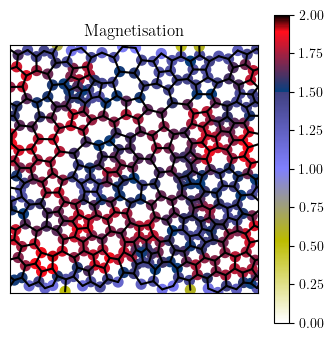

In [19]:
# generate the lattice and set the initial conditions

import koala.graph_utils

# create lattice
system_length = 20
lattice_type = "voronoi"
lattice = alter_lattice_maker(system_length, lattice_type)
lattice = koala.graph_utils.cut_boundaries(lattice, [False, True])

# set parameters
t1 = 1  # orbital parallel neighbor hopping
t2 = 0.5  # orbital perpendicular neighbor hopping
J = 0.5  # Interaction strength
filling = 0.4  # filling of the lattice
initial_m = np.full(lattice.n_vertices, 1)  # initial magnetization
initial_parameters = {
    "t1": t1,
    "t2": t2,
    "J": J,
    "filling": filling,
    "initial_m": initial_m,
}


m_values = hartree_fock(lattice, initial_parameters, 20)

hamiltonian = alt_hamiltonian(
    lattice,
    initial_parameters["t1"],
    initial_parameters["t2"],
    initial_parameters["J"],
    m_values[-1],
)
energies, states = la.eigh(hamiltonian)

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
pl.plot_edges(lattice, ax=ax)
im = ax.scatter(
    lattice.vertices.positions[:, 0],
    lattice.vertices.positions[:, 1],
    c=m_values[-1],
    cmap="gist_stern_r",
    s=50,
    vmin=0,
    vmax=2,
)
plt.colorbar(im, ax=ax)
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Magnetisation")
print(lattice)

In [ ]:
# recap of what we have to work with
hamiltonian
lattice

Lattice(400 vertices, 583 edges)